In [27]:
%reload_ext autoreload

from helper import fitting, models, plot
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd
import sys
import os

In [28]:
def get_dir():
    if sys.platform == "win32": # windows
        dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\vis_test (caprese) results"
    elif sys.platform == "darwin": # mac
        dir = "/Volumes/Coolens_Research/Isaac/Experiments/vis_test (caprese) results"
    else:
        raise ValueError("Unable to get directory.")

    return dir

def import_dat(boundary = True):
    dir = get_dir()
    keys = ["depth_df", "time_df", "conc_df"]
    files = ["vis_x.csv", "vis_time.csv", "vis_conc_xt.csv"]
    if boundary:
        folder = os.path.join(dir, "boundary_true")
    else:
        folder = os.path.join(dir, "boundary_false")

    folders = {k: os.path.join(folder, v) for k, v in zip(keys, files)}
    out = {k: pd.read_csv(folders[k], dtype = float) for k in keys}

    return out

In [29]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[6:30]
depth = depth - np.nanmin(depth)
conc = conc[:, 6:30]

In [30]:
dat = import_dat(boundary = True)

conc, depth, time = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth = depth.flatten()
time = time.flatten()

depth = depth[:23]
conc = conc[:, :23]

# Manually selected (initial drop -> interface, flattened)
#depth = depth[6:24]
#depth = depth - np.nanmin(depth)
#conc = conc[:, 6:24]

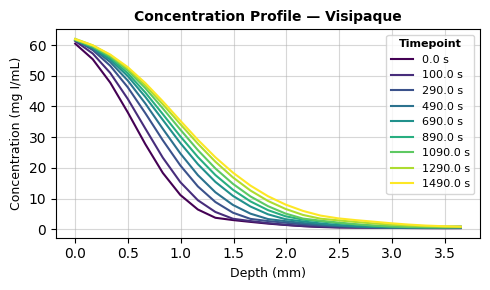

In [31]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

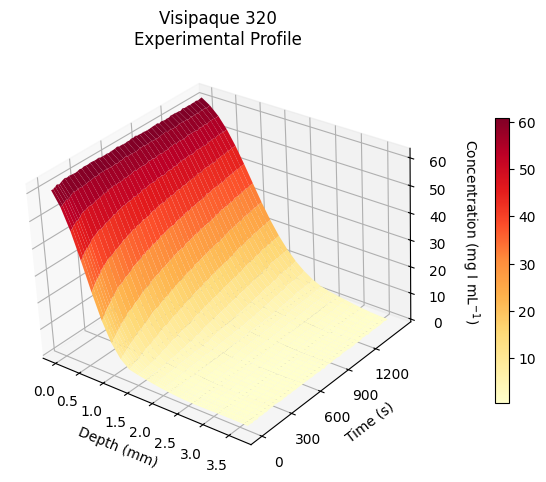

In [32]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# Fitting

In [33]:
first_row = conc[:, 0]
cs_experimental = np.nanmean(first_row)

configs = []

for model in fitting.MODEL_REGISTRY:
    for fit_x0 in [False, True]:
        for cs_mode in fitting.VALID_CS_MODES:
            for d_mode in fitting.VALID_D_MODES:
                if cs_mode == "fixed" and model == "semi-infinite":
                    cs_fixed = cs_experimental
                elif cs_mode == "fixed" and model == "infinite":
                    cs_fixed = 2 * cs_experimental
                else:
                    cs_fixed = None

                cfg = fitting.FitConfig(
                    model = model,
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_fixed
                )
                configs.append(cfg)

print(f"Total configs: {len(configs)}")

Total configs: 24


In [34]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

on 0: Using model: semi-infinite --> semi_infinite                              
on 1: Using model: semi-infinite --> semi_infinite                              
on 2: Using model: semi-infinite --> semi_infinite                              |█▋                                      | ▆█▆ 1/24 [4%] in 0s (
on 3: Using model: semi-infinite --> semi_infinite                              
on 4: Using model: semi-infinite --> semi_infinite                              
on 5: Using model: semi-infinite --> semi_infinite                              
on 6: Using model: semi-infinite --> semi_infinite                              
on 7: Using model: semi-infinite --> semi_infinite                              
on 8: Using model: semi-infinite --> semi_infinite                              
on 9: Using model: semi-infinite --> semi_infinite                              
on 10: Using model: semi-infinite --> semi_infinite                             
on 11: Using model: semi-infinite --> semi_in

In [35]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)
    x0_summary = np.nanmedian(r.x0_per_t) if cfg.fit_x0 else np.nan
    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "D": d_summary,
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "Median x0": x0_summary,
        "R2": r.r2_global,
        "RMSE_mean": np.nanmean(r.rmse_per_t) if r.rmse_per_t is not None else np.nan,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df = pd.DataFrame(rows)
summary_df["delta_aic"] = summary_df["AIC"] - summary_df["AIC"].min()
summary_df["delta_bic"] = summary_df["BIC"] - summary_df["BIC"].min()
summary_df.sort_values("delta_aic")
summary_df

,model,fit_x0,d_mode,cs_mode,D,Cs,Median x0,R2,RMSE_mean,AIC,BIC,n_params,delta_aic,delta_bic
0,semi-infinite,False,global,fixed,0.001160,61.624955,NaN,0.897309,5.859983,6875.164719,6880.682240,1,4.609688e+03,3.527331e+03
1,semi-infinite,False,per-timepoint,fixed,0.001112,61.624955,NaN,0.976991,3.258144,4445.647163,4887.048831,80,2.180170e+03,1.533698e+03
2,semi-infinite,False,global,global,0.001022,66.776043,NaN,0.903288,5.557582,6747.526675,6758.561717,2,4.482050e+03,3.405211e+03
3,semi-infinite,False,per-timepoint,global,0.000962,67.926451,NaN,0.986825,2.525643,3410.488989,3857.408178,81,1.145012e+03,5.040570e+02
4,semi-infinite,False,global,per-timepoint,0.001083,66.328613,NaN,0.914020,5.247728,6689.018557,7135.937746,81,4.423541e+03,3.782587e+03
5,semi-infinite,False,per-timepoint,per-timepoint,0.000957,68.126728,NaN,0.986962,2.512569,3551.601749,4434.405085,160,1.286125e+03,1.081054e+03
6,semi-infinite,True,global,fixed,0.001016,61.624955,0.095463,0.934041,4.607745,6201.314765,6648.233954,81,3.935838e+03,3.294883e+03
7,semi-infinite,True,per-timepoint,fixed,0.000839,61.624955,0.147584,0.988608,2.348463,3301.273029,4184.076365,160,1.035796e+03,8.307252e+02
8,semi-infinite,True,global,global,0.000668,45.102615,0.498000,0.952507,4.008203,5606.622617,6059.059327,82,3.341145e+03,2.705708e+03
9,semi-infinite,True,per-timepoint,global,0.000609,48.706678,0.455693,0.992777,1.915625,2465.030312,3353.351169,161,1.995532e+02,1.710623e-08


In [43]:
0.166*3

0.498

In [36]:
cfg = [c for c in configs if (c.d_mode == "global" and c.cs_mode == "per-timepoint" and c.fit_x0 == True)]

In [37]:
cs_per_t = [r.cs_per_t for r in results if r.config in cfg]
x0_per_t = [r.x0_per_t for r in results if r.config in cfg]

In [38]:
cs_per_t

[array([        nan, 30.91400655, 29.4250731 , 31.80605484, 34.29800735,
        36.42366045, 38.04997928, 39.12091916, 40.25137835, 41.41277864,
        42.43696668, 43.4130788 , 45.04048598, 45.96291312, 47.15035306,
        47.95556326, 48.71402497, 49.43343425, 50.21340228, 51.13827744,
        51.6609962 , 52.43208263, 53.03674833, 53.43614669, 54.42057375,
        55.24692828, 55.70850149, 56.20308619, 57.20718805, 57.6055874 ,
        58.74604591, 58.99779602, 60.35156792, 61.09065973, 62.20855206,
        62.82540276, 63.7374515 , 65.64303289, 65.72706674, 67.13455162,
        68.15391516, 69.48871793, 70.3532157 , 71.90443906, 72.86480897,
        72.91343526, 74.56578004, 74.27979609, 74.83536127, 75.24955881,
        76.03077198, 76.16988015, 76.82951387, 77.15716272, 77.53970667,
        78.09325161, 78.86825199, 79.59773763, 78.46353264, 79.78045144,
        79.99024495, 79.44890791, 79.71429802, 79.58547264, 80.99492644,
        81.02350534, 81.78732964, 80.74051123, 81.5

In [39]:
target_configs = [cfg for cfg in configs if (cfg.d_mode == "per-timepoint" and cfg.cs_mode in ["global", "fixed"] and cfg.fit_x0 == True)]

d_per_t = []
cs_global = []
x0_per_t = []

for r in results:
    if r.config in target_configs:
        d_per_t.append(r.d_per_t)
        x0_per_t.append(r.x0_per_t)
        if r.config.model == "infinite":
            cs_global.append(r.cs_global * 0.5)
        else:
            cs_global.append(r.cs_global)

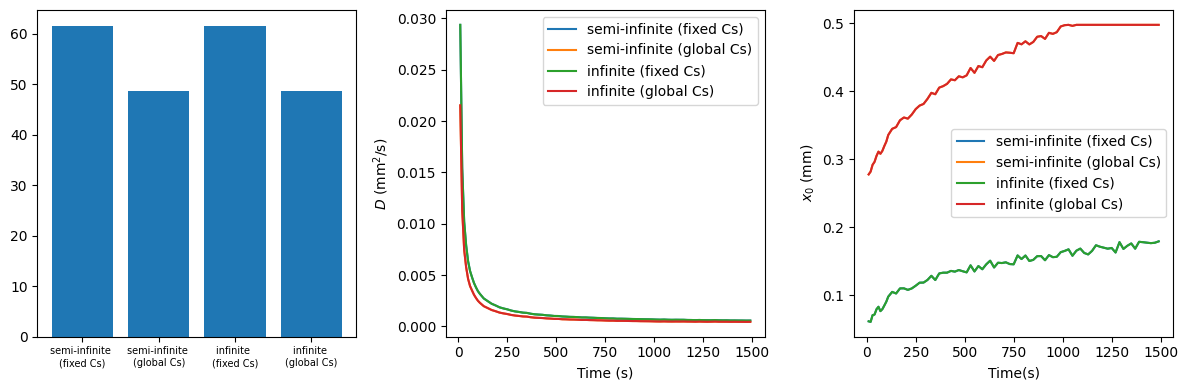

In [40]:
to_plot = zip(target_configs, d_per_t, x0_per_t)

fig, ax = plt.subplots(1, 3, figsize = (12, 4))
cs = ax[0]
d = ax[1]
x0 = ax[2]

labs = [f"{cfg.model} \n({cfg.cs_mode} Cs)" for cfg in target_configs]
cs.bar(labs, cs_global)
cs.tick_params(axis = "x", labelsize = 7)
cs.set_ylabel("")

for cfg, d_cfg, x0_cfg in to_plot:
    label = f"{cfg.model} ({cfg.cs_mode} Cs)"
    d.plot(time, d_cfg, label = label)
    x0.plot(time, x0_cfg, label = label)

d.legend()
d.set_ylabel(f"$D$ (mm$^2$/s)")
d.set_xlabel("Time (s)")

x0.set_ylabel(f"$x_0$ (mm)")
x0.set_xlabel("Time(s)")
x0.legend()
plt.tight_layout()
plt.show()

In [41]:
config_semi = fitting.FitConfig(model = "semi-infinite",
                        fit_x0 = False,
                        d_mode = "per-timepoint", 
                        cs_mode = "fixed",
                        cs_fixed = cs_experimental)

config_inf = fitting.FitConfig(model = "infinite",
                        fit_x0 = False,
                        d_mode = "per-timepoint", 
                        cs_mode = "fixed",
                        cs_fixed = cs_experimental)

result_semi = fitting.fit_diffusion(conc, depth, time, config_semi)
result_inf = fitting.fit_diffusion(conc, depth, time, config_inf)

Using model: semi-infinite --> semi_infinite
Using model: infinite --> infinite


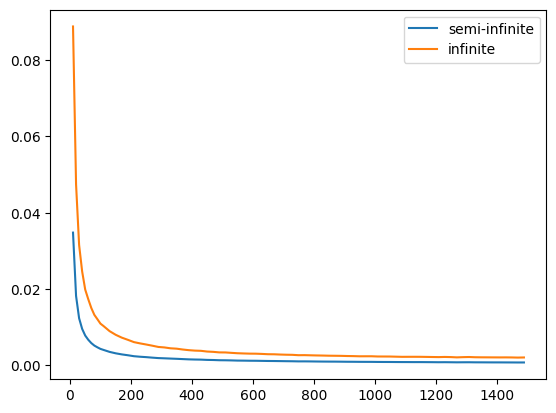

In [42]:
fig, ax = plt.subplots()
ax.plot(time, result_semi.d_per_t, label = "semi-infinite")
ax.plot(time, result_inf.d_per_t, label = "infinite")
ax.legend()
plt.show()